# Heat budget validation


We will run a heat budget in our extended MOM6-Panan simulations. For taht, we need to first check wether we can close the heat budget terms , in a short time-length before rerunning the model for greater lentghs.

[Here](https://gist.github.com/marshallward/4fd99af6d1a05dbdca02123ec5aef04c) shows an eaxample of a heat budget for mom6. let's see if it closes in our simulations, and both in z and sigma coords

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio
import cmocean.cm as cm

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [2]:
client = Client(threads_per_worker = 1)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

importing data

In [5]:
%%time
input_dir = '/scratch/oz91/wf4500/Panan01_extension_18Nov2025/wf4500/mom6/archive/mom6-panan-panan-01-1ac3e236/output001/'

#import monthly heat budget fields
ocean_month = xr.open_dataset(input_dir + '20010101.ocean_month.nc')
ocean_month_z = xr.open_dataset(input_dir + '20010101.ocean_month_z.nc')
ocean_month_rho2 = xr.open_dataset(input_dir + '20010101.ocean_month_rho2.nc')
ocean_static = xr.open_dataset(input_dir + '20010101.ocean_static.nc')

CPU times: user 5.67 s, sys: 2.3 s, total: 7.97 s
Wall time: 8.28 s


### Vertically integrated budget

from $ocean\_month$, 2d outputs

In [17]:
timestamp = 1

##  total online term ######################################
# Tendency of Sea Water Potential Temperature Expressed as Heat Content Vertical Sum [W] (integrated)
OPOTTEMPTEND  = (ocean_month.opottemptend_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))

## Individual online terms to sum up ######################################
# Vertical sum of horizontal convergence of residual mean advective fluxes of heat [W] (integrated)
T_ADVECTION_XY = (ocean_month.T_advection_xy_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))
# Vertical sum of vertical remapping tracer content tendency for Heat [W] (integrated)
TH_TENDENCY_VERT_REMAP = (ocean_month.Th_tendency_vert_remap_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized dianeutral mixing depth integrated [W] (integrated)
OPOTTEMPDIFF = (ocean_month.opottempdiff_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized mesoscale neutral diffusion [W] (integrated)
OPOTTEMPPMDIFF = (ocean_month.opottemppmdiff_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated boundary forcing of ocean heat  [W] (integrated)
BOUNDARY_FORCING_HEAT_TENDENCY = (ocean_month.boundary_forcing_heat_tendency_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated heat tendency due to frazil formation  [W] (integrated)
FRAZIL_HEAT_TENDENCY = (ocean_month.frazil_heat_tendency_2d.isel(time=0) * ocean_static.areacello).sum(('xh','yh'))




## Summing up individual terms
OPOTTEMPTEND_offline = T_ADVECTION_XY + TH_TENDENCY_VERT_REMAP + OPOTTEMPDIFF + OPOTTEMPPMDIFF + BOUNDARY_FORCING_HEAT_TENDENCY  + FRAZIL_HEAT_TENDENCY

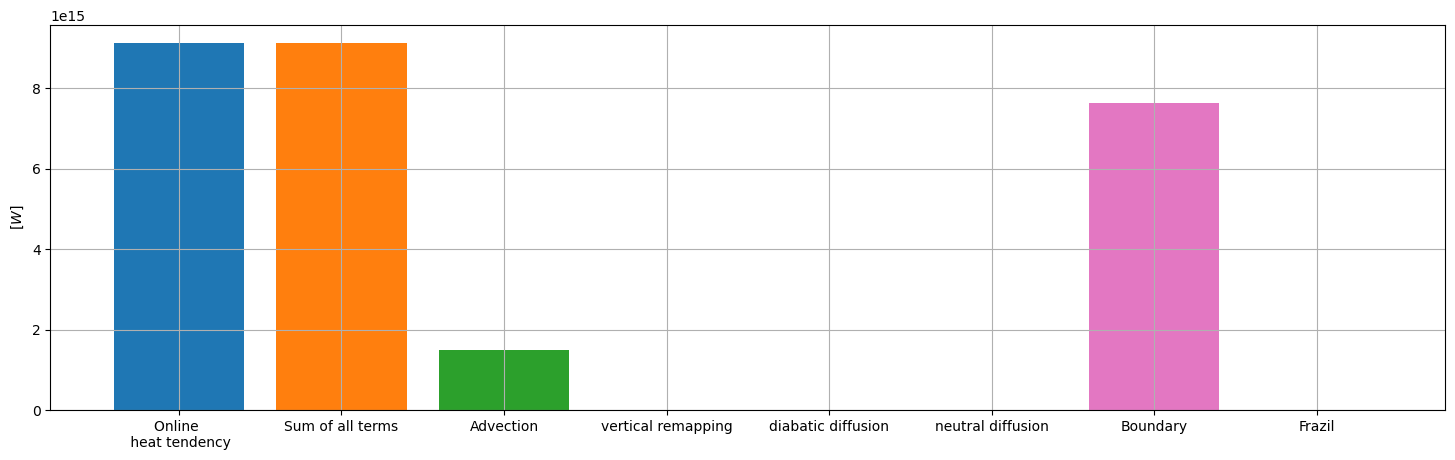

In [33]:
fig = plt.figure(figsize=(18,5))

plt.bar(0,OPOTTEMPTEND )
plt.bar(1,OPOTTEMPTEND_offline )
plt.bar(2,T_ADVECTION_XY )
plt.bar(3,TH_TENDENCY_VERT_REMAP )
plt.bar(4,OPOTTEMPDIFF )
plt.bar(5,OPOTTEMPPMDIFF )
plt.bar(6,BOUNDARY_FORCING_HEAT_TENDENCY )
plt.bar(7,FRAZIL_HEAT_TENDENCY )
plt.xticks(ticks = [0,1,2,3,4,5,6,7],labels =[ 'Online \n heat tendency','Sum of all terms','Advection','Vertical remapping','Diabatic diffusion','Neutral diffusion','Boundary'\
                                              ,'Frazil'])
plt.ylabel(r'[$W$]')
plt.grid()


Seems reasonable to me - tho it is interesting that the vertically integrated heat flux is largely dominated by boundary forcing

### Heat flux over a single z* layer

Let's now check if the heat budget also closes at a single layer. For testing Ill try 1000 m depth

In [38]:
depth_target = 1000 #m
timestamp = 1

##  total online term ######################################
# Tendency of Sea Water Potential Temperature Expressed as Heat Content Vertical Sum [W] (integrated)
OPOTTEMPTEND  = (ocean_month_z.opottemptend.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))

## Individual online terms to sum up ######################################
# Vertical sum of horizontal convergence of residual mean advective fluxes of heat [W] (integrated)
T_ADVECTION_XY = (ocean_month_z.T_advection_xy.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Vertical sum of vertical remapping tracer content tendency for Heat [W] (integrated)
TH_TENDENCY_VERT_REMAP = (ocean_month_z.Th_tendency_vert_remap.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized dianeutral mixing depth integrated [W] (integrated)
OPOTTEMPDIFF = (ocean_month_z.opottempdiff.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized mesoscale neutral diffusion [W] (integrated)
OPOTTEMPPMDIFF = (ocean_month_z.opottemppmdiff.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated boundary forcing of ocean heat  [W] (integrated)
BOUNDARY_FORCING_HEAT_TENDENCY = (ocean_month_z.boundary_forcing_heat_tendency.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated heat tendency due to frazil formation  [W] (integrated)
FRAZIL_HEAT_TENDENCY = (ocean_month_z.frazil_heat_tendency.isel(time=0).sel(z_l=depth_target,method='nearest') * ocean_static.areacello).sum(('xh','yh'))




## Summing up individual terms
OPOTTEMPTEND_offline = T_ADVECTION_XY + TH_TENDENCY_VERT_REMAP + OPOTTEMPDIFF + OPOTTEMPPMDIFF + BOUNDARY_FORCING_HEAT_TENDENCY  + FRAZIL_HEAT_TENDENCY

Text(0.5, 1.0, 'Heat budget at 1000 m depth')

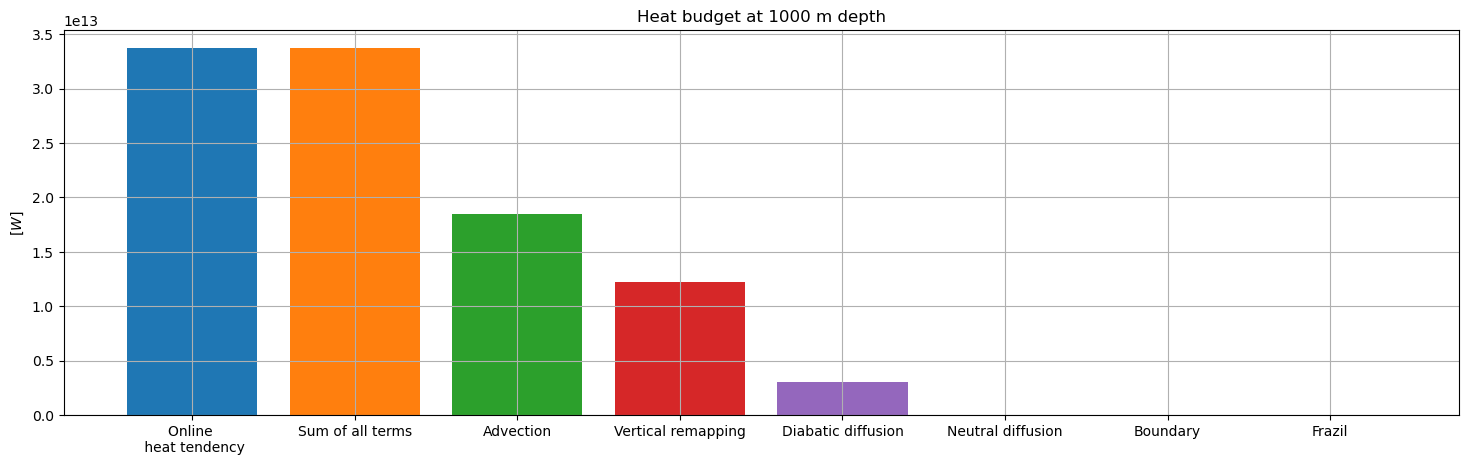

In [39]:
fig = plt.figure(figsize=(18,5))

plt.bar(0,OPOTTEMPTEND )
plt.bar(1,OPOTTEMPTEND_offline )
plt.bar(2,T_ADVECTION_XY )
plt.bar(3,TH_TENDENCY_VERT_REMAP )
plt.bar(4,OPOTTEMPDIFF )
plt.bar(5,OPOTTEMPPMDIFF )
plt.bar(6,BOUNDARY_FORCING_HEAT_TENDENCY )
plt.bar(7,FRAZIL_HEAT_TENDENCY )
plt.xticks(ticks = [0,1,2,3,4,5,6,7],labels =[ 'Online \n heat tendency','Sum of all terms','Advection','Vertical remapping','Diabatic diffusion','Neutral diffusion','Boundary'\
                                              ,'Frazil'])
plt.ylabel(r'[$W$]')
plt.grid()
plt.title('Heat budget at ' + str(depth_target) + ' m depth')

budget closes here too. Interesting tho that at this depth loca advection, and vertical remapping are basically the most important ones, with Diabatic Diffusion playing a terciary role

### Heat flux over a single $\sigma$ layer

Let's now check if the heat budget also closes at a single $\sigma$ layer. For testing Ill try 1000 m depth

In [53]:
rho_target = ocean_month_rho2.isel(time=0).opottemptend.isel(rho2_l=50).rho2_l
timestamp = 1

##  total online term ######################################
# Tendency of Sea Water Potential Temperature Expressed as Heat Content Vertical Sum [W] (integrated)
OPOTTEMPTEND  = (ocean_month_rho2.opottemptend.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))

## Individual online terms to sum up ######################################
# Vertical sum of horizontal convergence of residual mean advective fluxes of heat [W] (integrated)
T_ADVECTION_XY = (ocean_month_rho2.T_advection_xy.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Vertical sum of vertical remapping tracer content tendency for Heat [W] (integrated)
TH_TENDENCY_VERT_REMAP = (ocean_month_rho2.Th_tendency_vert_remap.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized dianeutral mixing depth integrated [W] (integrated)
OPOTTEMPDIFF = (ocean_month_rho2.opottempdiff.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Tendency of sea water potential temperature expressed as heat content due to parameterized mesoscale neutral diffusion [W] (integrated)
OPOTTEMPPMDIFF = (ocean_month_rho2.opottemppmdiff.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated boundary forcing of ocean heat  [W] (integrated)
BOUNDARY_FORCING_HEAT_TENDENCY = (ocean_month_rho2.boundary_forcing_heat_tendency.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))
# Depth integrated heat tendency due to frazil formation  [W] (integrated)
FRAZIL_HEAT_TENDENCY = (ocean_month_rho2.frazil_heat_tendency.isel(time=0).sel(rho2_l=rho_target ,method='nearest') * ocean_static.areacello).sum(('xh','yh'))




## Summing up individual terms
OPOTTEMPTEND_offline = T_ADVECTION_XY + TH_TENDENCY_VERT_REMAP + OPOTTEMPDIFF + OPOTTEMPPMDIFF + BOUNDARY_FORCING_HEAT_TENDENCY  + FRAZIL_HEAT_TENDENCY

Text(0.5, 1.0, 'Heat budget at $\\sigma_2$ = 1036.63 $kg \\ m^{-3}$')

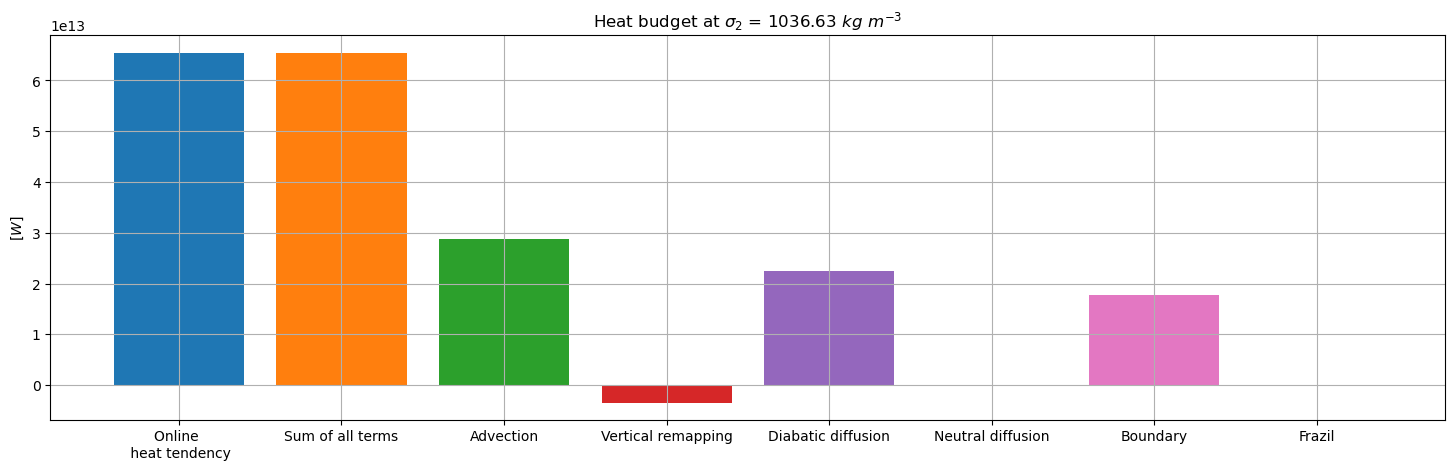

In [57]:
fig = plt.figure(figsize=(18,5))

plt.bar(0,OPOTTEMPTEND )
plt.bar(1,OPOTTEMPTEND_offline )
plt.bar(2,T_ADVECTION_XY )
plt.bar(3,TH_TENDENCY_VERT_REMAP )
plt.bar(4,OPOTTEMPDIFF )
plt.bar(5,OPOTTEMPPMDIFF )
plt.bar(6,BOUNDARY_FORCING_HEAT_TENDENCY )
plt.bar(7,FRAZIL_HEAT_TENDENCY )
plt.xticks(ticks = [0,1,2,3,4,5,6,7],labels =[ 'Online \n heat tendency','Sum of all terms','Advection','Vertical remapping','Diabatic diffusion','Neutral diffusion','Boundary'\
                                              ,'Frazil'])
plt.ylabel(r'[$W$]')
plt.grid()
plt.title(r'Heat budget at $\sigma_2$ = ' + str(np.round(rho_target.values,2) ) + r' $kg \ m^{-3}$')

Budget here seems to close correctly here too. We can move on and continue the simulation and run the simulation in other resolutions too